## Table of contents
- embedded methods:
    - plot feature importance based on the curated XGBoost Model.
    - plotting the decision boundaries of the XGBoost Model.
    - use a logistic regression / SVM model to re-affirm the features which are most -> L1-Lasso regularized models.
- wrapper methods:
    - feature permutation importance.
    - sequential feature selection;
        both using the random forest classifier.

### Re-doing the XGBoost Model from earlier.

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

In [2]:
import glob
files = glob.glob("../data/*/*")
files

['../data/s5e6/test.csv',
 '../data/s5e6/previous_competition.csv',
 '../data/s5e6/train.csv',
 '../data/s5e6/sample_submission.csv']

In [3]:
train_df = pd.read_csv(files[2])
test_df = pd.read_csv(files[0])
original_df = pd.read_csv(files[1])
submission_df = pd.read_csv(files[3])

In [4]:
train_df.columns

Index(['id', 'Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name'],
      dtype='object')

In [5]:
original_df.columns

Index(['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name'],
      dtype='object')

In [6]:
target_feature = list(train_df.columns)[-1]
numerical_features = [x for x in train_df.describe().columns if x != "id"]
categorical_features = [x for x in train_df.columns if x not in numerical_features and x != "id" and x != target_feature]
numerical_features, categorical_features

(['Temparature',
  'Humidity',
  'Moisture',
  'Nitrogen',
  'Potassium',
  'Phosphorous'],
 ['Soil Type', 'Crop Type'])

In [7]:
train_df = train_df.drop(columns = ["id"])
train_df = pd.concat([train_df, original_df], ignore_index = True)
train_df.tail(10)

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
849990,36,59,32,Sandy,Wheat,34,17,17,28-28
849991,26,54,30,Black,Millets,35,14,0,20-20
849992,27,50,47,Black,Paddy,22,7,28,20-20
849993,36,68,38,Sandy,Paddy,19,1,4,20-20
849994,32,51,45,Clayey,Paddy,27,8,2,20-20
849995,32,71,61,Black,Tobacco,23,1,25,20-20
849996,35,72,47,Loamy,Millets,38,1,32,17-17-17
849997,28,50,61,Sandy,Maize,10,11,14,14-35-14
849998,29,57,63,Loamy,Ground Nuts,7,10,4,DAP
849999,25,72,42,Sandy,Wheat,38,2,6,17-17-17


In [8]:
train_df[target_feature]

0            28-28
1            28-28
2         17-17-17
3         10-26-26
4              DAP
            ...   
849995       20-20
849996    17-17-17
849997    14-35-14
849998         DAP
849999    17-17-17
Name: Fertilizer Name, Length: 850000, dtype: object

In [9]:
## transformation of the categorical features.
oe = OrdinalEncoder()
train_df[categorical_features] = oe.fit_transform(train_df[categorical_features])
test_df[categorical_features] = oe.transform(test_df[categorical_features])
for col in categorical_features:
    train_df[col] = train_df[col].astype("category")
    test_df[col] = test_df[col].astype("category")

## transformation of the label.
le = LabelEncoder()
train_df[target_feature] = le.fit_transform(train_df[target_feature])
train_df.head()

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,37,70,36,1.0,8.0,36,4,5,4
1,27,69,65,4.0,4.0,30,6,18,4
2,29,63,32,4.0,4.0,24,12,16,2
3,35,62,54,4.0,0.0,39,12,4,0
4,35,58,43,3.0,6.0,37,2,16,5


In [10]:
full_y, full_x = train_df[target_feature], train_df.drop(columns = [target_feature])
train_x, test_x, train_y, test_y = train_test_split(full_x, full_y, test_size = 0.1, random_state = 42, stratify = full_y) ## use a lower test size fraction to get maximal results.

In [11]:
## settings from the designated notebook.
model_xg_multi = XGBClassifier(
    objective = "multi:softprob",
    num_class = len(np.unique(train_y)),
    n_estimators = 2000,
    learning_rate = 0.05,
    max_depth = 12,
    colsmaple_bytree = 0.467,
    early_stopping_rounds = 100,
    reg_alpha = 2.7,
    reg_lambda = 1.4,
    gamma = 0.26,
    enable_categorical = True,
    tree_method = 'hist',
    max_delta_step = 4,
    subsample = 0.86,
    random_state = 13,
    device = "cuda"
)
model_xg_multi.fit(train_x, train_y, eval_set = [(test_x, test_y)], verbose = 0)

/Users/abhishekmish/Documents/repos/kaggle_playground/.venv/lib/python3.12/site-packages/xgboost/callback.py:386: UserWarning: [10:47:08] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
  self.starting_round = model.num_boosted_rounds()
/Users/abhishekmish/Documents/repos/kaggle_playground/.venv/lib/python3.12/site-packages/xgboost/callback.py:386: UserWarning: [10:47:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "colsmaple_bytree" } are not used.

  self.starting_round = model.num_boosted_rounds()


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, colsmaple_bytree=0.467, device='cuda',
              early_stopping_rounds=100, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.26, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=4,
              max_depth=12, max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=2000,
              n_jobs=None, ...)

In [12]:
def predict_and_score_xgboost_multi(model):
    y_pred_probs = model.predict_proba(test_x)
    top3_probs = np.argsort(y_pred_probs, axis = 1)[:, -3:][:, ::-1]
    get_best_and_full_accuracy_xgboost(test_y, top3_probs)

    return top3_probs

def _get_score(actual, predicted):
    score = 0.0
    hits = 0
    seen = set()
    for i, pred in enumerate(predicted):
        if pred == np.int64(actual) and pred not in seen:
            hits += 1
            score += hits / (i + 1.0)
            seen.add(pred)
    
    return score ## since actual is ONE entity.


def get_best_and_full_accuracy_xgboost(ptest_y, topk_probs):
    test_yl = ptest_y.tolist()
    first_acc_l = [x for idx, x in enumerate(test_yl) if np.int64(x) == topk_probs[idx][0]]
    score_accl_l = [_get_score(x ,topk_probs[idx]) for idx, x in enumerate(test_yl)]

    print(f"First accuracy: {(len(first_acc_l) / len(test_yl)):.2f}") ## only based on the highest class.
    print(f"Score accuracy: {(np.mean(score_accl_l)):.2f}") ## based on the function defined earlier.

top3_xg_multi = predict_and_score_xgboost_multi(model_xg_multi)

First accuracy: 0.21
Score accuracy: 0.35


### Plot the importance of the features here.

/var/folders/nj/yxdzffl952qbglpsnwvv19q80000gn/T/ipykernel_93685/650001100.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(10), x='Importance', y='Feature', palette='viridis')


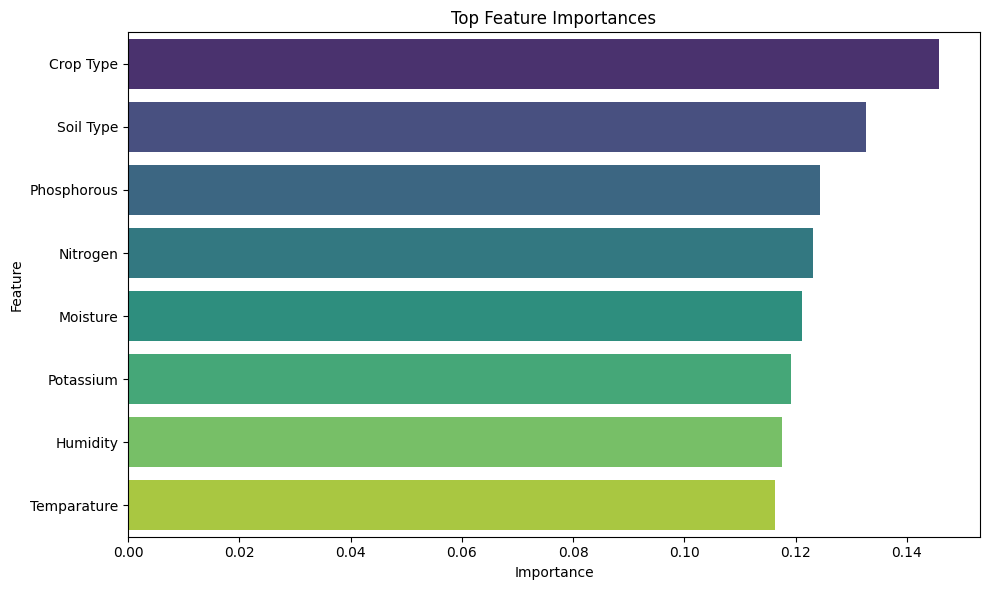

In [13]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
import seaborn as sns

importances = model_xg_multi.feature_importances_
feature_names = model_xg_multi.get_booster().feature_names

df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by = 'Importance', ascending = False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title("Top Feature Importances")
plt.tight_layout()
plt.show()

### Using L1-regularized Lasso logistic regression -> coefficients method to identify feature importance.

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#### collate one vs. all data for each class.

In [15]:
def create_balanced_splits():
    train_splits = {}
    for t in range(len(le.classes_)):
        pos_idx = train_y[train_y == t].index
        pos_samples = train_x.loc[pos_idx]
        pos_labels = train_y.loc[pos_idx]

        n_pos = len(pos_idx)
        neg_idx = train_y[train_y != t].index
        neg_x = train_x.loc[neg_idx]
        neg_y = train_y.loc[neg_idx]
        
        neg_x_sampled, _, neg_y_sampled, _ = train_test_split(neg_x, neg_y, train_size = n_pos, stratify = neg_y, random_state = 42)
        binary_x = pd.concat([pos_samples, neg_x_sampled])
        binary_y = pd.Series([1] * n_pos + [0] * n_pos, index = binary_x.index)

        ## shuffle.
        binary_x = binary_x.sample(frac = 1, random_state = 42)
        binary_y = binary_y.loc[binary_x.index]

        train_splits[t] = (binary_x, binary_y)
    
    return train_splits

In [16]:
balanced_splits = create_balanced_splits()

In [17]:
def fit_logistic_regression_l1_reg(X_train, y_train):
    # Standardize features
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(X_train)

    # Logistic Regression with L1 penalty (Lasso)
    logreg_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42)
    logreg_l1.fit(x_train_scaled, y_train)

    # Get coefficients
    coef = logreg_l1.coef_.ravel()

    # Select features with non-zero coefficients
    return coef
    # selected_features = train_df.columns[coef != 0]
    # print(f"Selected Features for feature {feature_name}: ")
    # print(selected_features.tolist())

In [18]:
coeff_dict = {}
for target_name, (ptrain_x, ptrain_y) in balanced_splits.items():
    coeffs = fit_logistic_regression_l1_reg(ptrain_x, ptrain_y)
    cols = ptrain_x.columns
    ## sort the zipped coeffs, cols by coeff
    zipped_cols = list(zip(coeffs, cols))
    zipped_cols = list(sorted(zipped_cols, key = lambda x : -abs(x[0])))

    ## print the top -3
    print(f"Top 3 most important features for {le.classes_[target_name]}: ")
    top3_cols = zipped_cols[:3]
    print(top3_cols)

    for coeff, col in zipped_cols:
        if col not in coeff_dict.keys():
            coeff_dict[col] = 0
        coeff_dict[col] += abs(coeff)

    # coeff_dict[feature_name] = coeffs
    # print(f"For feature {feature_name}: ")
    # selected_features = ptrain_x.columns[coeffs != 0]
    # print(f"Selected features are: {selected_features}")

Top 3 most important features for 10-26-26: 
[(np.float64(0.027987562968988345), 'Crop Type'), (np.float64(-0.02656374158764828), 'Soil Type'), (np.float64(0.022208512175297873), 'Potassium')]
Top 3 most important features for 14-35-14: 
[(np.float64(0.029649397440833346), 'Phosphorous'), (np.float64(-0.017455575089682544), 'Soil Type'), (np.float64(-0.008593888641924188), 'Humidity')]
Top 3 most important features for 17-17-17: 
[(np.float64(-0.038100455810824364), 'Moisture'), (np.float64(0.015556359493421516), 'Nitrogen'), (np.float64(0.011142403210334047), 'Potassium')]
Top 3 most important features for 20-20: 
[(np.float64(0.022062385809760734), 'Potassium'), (np.float64(0.01676702531320864), 'Crop Type'), (np.float64(0.012962712827347202), 'Moisture')]
Top 3 most important features for 28-28: 
[(np.float64(0.027861238077893143), 'Moisture'), (np.float64(0.021623546776037426), 'Soil Type'), (np.float64(-0.015866425332927574), 'Crop Type')]
Top 3 most important features for DAP: 
[

In [19]:
for feature, importance in coeff_dict.items():
    print("Feature: ", feature)
    print("Importance: ", importance)

Feature:  Crop Type
Importance:  0.11610455176095458
Feature:  Soil Type
Importance:  0.11124991435835371
Feature:  Potassium
Importance:  0.10962540367150589
Feature:  Humidity
Importance:  0.07481990295637736
Feature:  Nitrogen
Importance:  0.0625580024510162
Feature:  Temparature
Importance:  0.03600753012937541
Feature:  Moisture
Importance:  0.10139473757201707
Feature:  Phosphorous
Importance:  0.06388078492710361


#### Use random forest classifier with feature permutation importance to determine the feature importance.

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

In [21]:
rtrain_x, rtest_x, rtrain_y, rtest_y = train_test_split(full_x, full_y, test_size = 0.3, random_state = 42, stratify = full_y)
rf = RandomForestClassifier(random_state = 42)
rf.fit(rtrain_x, rtrain_y)

RandomForestClassifier(random_state=42)

In [22]:
from sklearn.metrics import accuracy_score
print(f"The accuracy score for the predictions is: {accuracy_score(rtest_y, rf.predict(rtest_x))}")

The accuracy score for the predictions is: 0.17369019607843136


In [23]:
perm_importance = permutation_importance(rf, rtest_x, rtest_y, n_repeats=30, random_state=42)

In [24]:
importance_df = pd.DataFrame({
    'feature': rtrain_x.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)
print("\n permutation feature importance: ")
print(importance_df)


 permutation feature importance: 
       feature  importance_mean  importance_std
4    Crop Type         0.012378        0.000669
7  Phosphorous         0.011965        0.000502
2     Moisture         0.009704        0.000591
5     Nitrogen         0.009250        0.000548
6    Potassium         0.008241        0.000637
3    Soil Type         0.007306        0.000521
1     Humidity         0.005742        0.000421
0  Temparature         0.005307        0.000676
